The analysis (see below) does not provide robust evidence that Trump’s second-term tariffs reduced imports. Results vary by specification, and the short second-term observation window limits inference. We will retain these findings as preliminary and revisit the question when more data are available.

In [1]:
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from pathlib import Path
import pandas as pd

# Locate the project folder.
project_dir = Path.cwd()
if project_dir.name == "notebooks":
    project_dir = project_dir.parent

# Load the prepared data and restore the date index.
analysis_df = pd.read_csv(
    project_dir / "data" / "processed" / "analysis_data.csv",
    index_col="date",
    parse_dates=["date"],
)

analysis_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 403 entries, 1993-01-01 to 2026-07-01
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   imports                   403 non-null    int64  
 1   exports                   403 non-null    int64  
 2   trade_balance             403 non-null    int64  
 3   trump_second_term         403 non-null    int64  
 4   imports_yoy_pct           403 non-null    float64
 5   exports_yoy_pct           403 non-null    float64
 6   trade_balance_yoy_change  403 non-null    float64
dtypes: float64(3), int64(4)
memory usage: 25.2 KB


In [3]:
import statsmodels.api as sm
from scipy.stats import t

# Outcome: year-over-year import growth.
y = analysis_df["imports_yoy_pct"]
X = sm.add_constant(analysis_df[["trump_second_term"]])

model = sm.OLS(y, X, missing="raise").fit(
    cov_type="HAC",
    cov_kwds={"maxlags": 12, "use_correction": True},
    use_t=True,
)

# H₀: beta >= 0 (growth was not lower)
# H₁: beta < 0  (growth was lower)
beta = model.params["trump_second_term"]
t_stat = model.tvalues["trump_second_term"]
p_one_sided = t.cdf(t_stat, df=model.df_resid)

print(model.summary())
print(f"\nDifference in import growth: {beta:.2f} percentage points")
print(f"One-sided p-value: {p_one_sided:.3f}")

                            OLS Regression Results                            
Dep. Variable:        imports_yoy_pct   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.3465
Date:                Sat, 26 Sep 2026   Prob (F-statistic):              0.556
Time:                        18:00:52   Log-Likelihood:                -1555.9
No. Observations:                 403   AIC:                             3116.
Df Residuals:                     401   BIC:                             3124.
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 6.5037      1.63

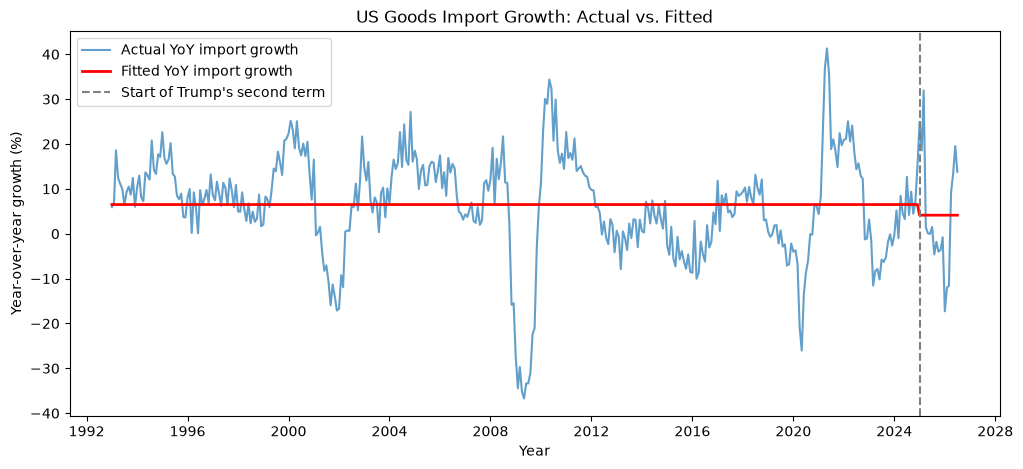

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    analysis_df.index,
    analysis_df["imports_yoy_pct"],
    label="Actual YoY import growth",
    alpha=0.7,
)

plt.plot(
    analysis_df.index,
    model.fittedvalues,
    label="Fitted YoY import growth",
    color="red",
    linewidth=2,
)

plt.axvline(
    pd.Timestamp("2025-01-01"),
    color="gray",
    linestyle="--",
    label="Start of Trump's second term",
)

plt.xlabel("Year")
plt.ylabel("Year-over-year growth (%)")
plt.title("US Goods Import Growth: Actual vs. Fitted")
plt.legend()
plt.show()

In [5]:
import numpy as np
import statsmodels.api as sm
from scipy.stats import t as t_dist

analysis_df = analysis_df.sort_index().copy()
analysis_df["time"] = np.arange(len(analysis_df))

X = sm.add_constant(
    analysis_df[["time", "trump_second_term"]]
)
y = analysis_df["imports"]

levels_model = sm.OLS(y, X, missing="raise").fit(
    cov_type="HAC",
    cov_kwds={"maxlags": 12, "use_correction": True},
    use_t=True,
)

# H₀: beta >= 0; H₁: beta < 0
p_one_sided = t_dist.cdf(
    levels_model.tvalues["trump_second_term"],
    df=levels_model.df_resid,
)

print(levels_model.summary())
print(f"\nOne-sided p-value: {p_one_sided:.3f}")

                            OLS Regression Results                            
Dep. Variable:                imports   R-squared:                       0.935
Model:                            OLS   Adj. R-squared:                  0.935
Method:                 Least Squares   F-statistic:                     694.5
Date:                Sat, 26 Sep 2026   Prob (F-statistic):          7.78e-131
Time:                        18:00:53   Log-Likelihood:                -4516.6
No. Observations:                 403   AIC:                             9039.
Df Residuals:                     400   BIC:                             9051.
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              4.572e+04   3234.96

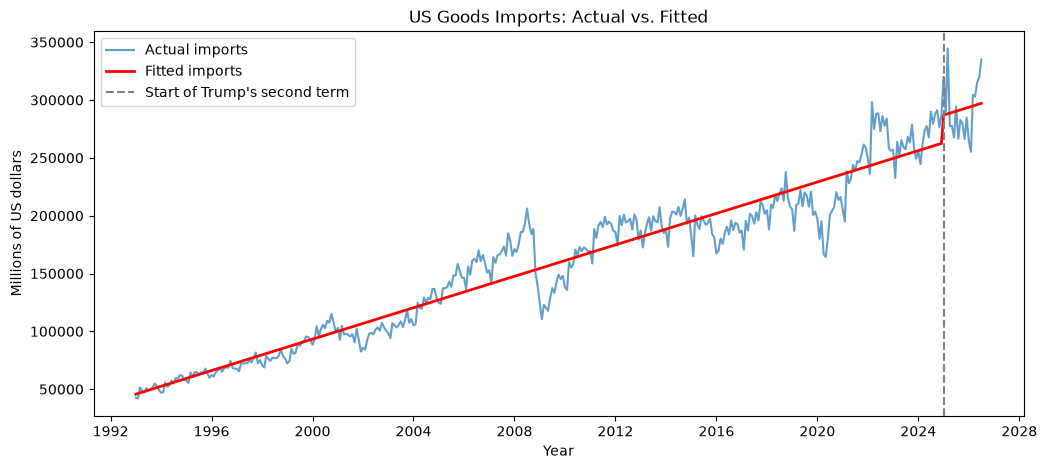

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    analysis_df.index,
    analysis_df["imports"],
    label="Actual imports",
    alpha=0.7,
)

plt.plot(
    analysis_df.index,
    levels_model.fittedvalues,
    label="Fitted imports",
    color="red",
    linewidth=2,
)

plt.axvline(
    pd.Timestamp("2025-01-01"),
    color="gray",
    linestyle="--",
    label="Start of Trump's second term",
)

plt.xlabel("Year")
plt.ylabel("Millions of US dollars")
plt.title("US Goods Imports: Actual vs. Fitted")
plt.legend()
plt.show()